# House Price Prediction

In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## Download Dataset

In [68]:
import urllib.request
import os

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
filename = "house_price_data.csv"

try:
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print(f"Dataset downloaded: {filename}")
    else:
        print(f"Dataset exists: {filename}")
except Exception as e:
    np.random.seed(42)
    n_samples = 5000
    sample_data = pd.DataFrame({
        'Area': np.random.randint(500, 5000, n_samples),
        'Bedrooms': np.random.randint(1, 6, n_samples),
        'Bathrooms': np.random.randint(1, 4, n_samples),
        'Stories': np.random.randint(1, 4, n_samples),
        'Parking': np.random.randint(0, 4, n_samples),
        'Age': np.random.randint(0, 50, n_samples),
    })
    sample_data['Price'] = (
        sample_data['Area'] * 150 +
        sample_data['Bedrooms'] * 50000 +
        sample_data['Bathrooms'] * 30000 +
        sample_data['Stories'] * 20000 +
        sample_data['Parking'] * 15000 -
        sample_data['Age'] * 2000 +
        np.random.normal(0, 50000, n_samples)
    )
    sample_data.to_csv(filename, index=False)
    print(f"Generated sample dataset: {filename}")

Dataset exists: house_price_data.csv


In [69]:
df = pd.read_csv("house_price_data.csv")
df = df.dropna()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=float)

if 'median_house_value' in df.columns:
    df = df.rename(columns={'median_house_value': 'Price'})
elif 'price' in df.columns:
    df = df.rename(columns={'price': 'Price'})

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col])

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (20433, 13)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income     Price  ocean_proximity_INLAND  \
0       322.0       126.0         8.3252  452600.0                     0.0   
1      2401.0      1138.0         8.3014  358500.0                     0.0   
2       496.0       177.0         7.2574  352100.0                     0.0   
3       558.0       219.0         5.6431  341300.0                     0.0   
4       565.0       259.0         3.8462  342200.0                     0.0   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  

## Exploratory Data Analysis

In [70]:
print(df.describe())
print(f"\nMissing Values:\n{df.isnull().sum()}")

          longitude      latitude  housing_median_age   total_rooms  \
count  20433.000000  20433.000000        20433.000000  20433.000000   
mean    -119.570689     35.633221           28.633094   2636.504233   
std        2.003578      2.136348           12.591805   2185.269567   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1450.000000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.720000           37.000000   3143.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20433.000000  20433.000000   20433.000000   
mean       537.870553   1424.946949    499.433465       3.871162   
std        421.385070   1133.208490    382.299226       1.899291   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

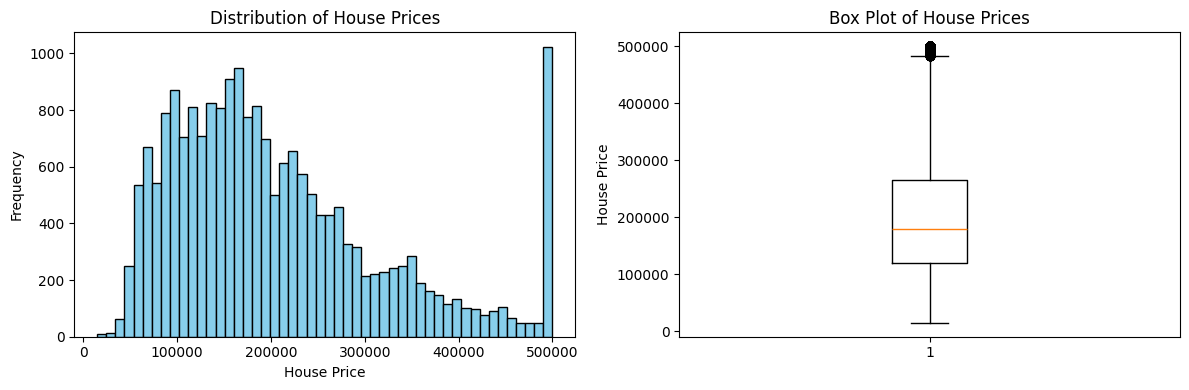

In [71]:
price_col = None
for col in df.columns:
    if 'price' in col.lower() or 'value' in col.lower():
        price_col = col
        break
if price_col is None:
    price_col = df.columns[-1]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df[price_col], bins=50, edgecolor='black', color='skyblue')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.subplot(1, 2, 2)
plt.boxplot(df[price_col])
plt.ylabel('House Price')
plt.title('Box Plot of House Prices')
plt.tight_layout()
plt.show()

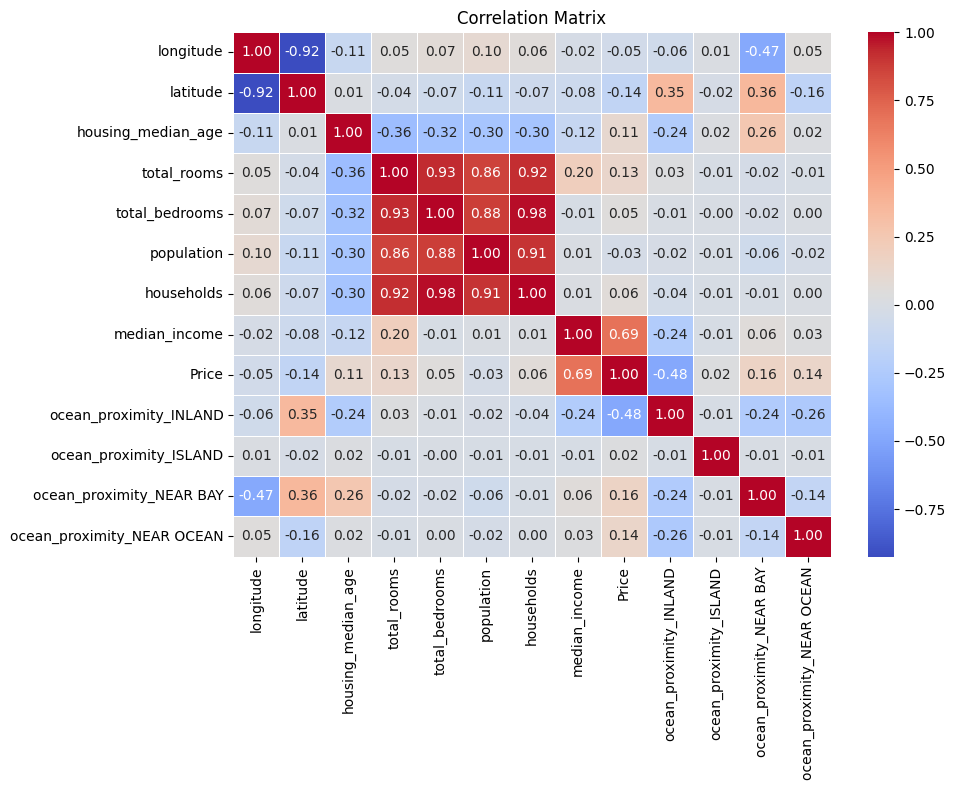

Price                         1.000000
median_income                 0.688355
ocean_proximity_NEAR BAY      0.160526
ocean_proximity_NEAR OCEAN    0.140378
total_rooms                   0.133294
housing_median_age            0.106432
households                    0.064894
total_bedrooms                0.049686
ocean_proximity_ISLAND        0.023525
population                   -0.025300
longitude                    -0.045398
latitude                     -0.144638
ocean_proximity_INLAND       -0.484787
Name: Price, dtype: float64


In [72]:
price_col = None
for col in df.columns:
    if 'price' in col.lower() or 'value' in col.lower():
        price_col = col
        break
if price_col is None:
    price_col = df.columns[-1]

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print(correlation_matrix[price_col].sort_values(ascending=False))

## Data Preprocessing

In [73]:
price_col = None
for col in df.columns:
    if 'price' in col.lower() or 'value' in col.lower():
        price_col = col
        break
if price_col is None:
    price_col = df.columns[-1]

X = df.drop(price_col, axis=1)
y = df[price_col]

print(f"Features: {X.shape}, Target: {y.shape}")

Features: (20433, 12), Target: (20433,)


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 16346, Test: 4087


In [75]:
non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    raise ValueError(f"Non-numeric columns: {non_numeric}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


## Model Training

In [76]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained")

Linear Regression trained
Decision Tree trained
Decision Tree trained
Random Forest trained
Random Forest trained


## Model Evaluation

In [77]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2
    })
    
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

results_df = pd.DataFrame(results)
print(f"\n{results_df.to_string(index=False)}")

Linear Regression: RMSE=69297.7167, MAE=50413.4333, R²=0.6488
Decision Tree: RMSE=67676.6484, MAE=42997.2542, R²=0.6651
Random Forest: RMSE=48777.7877, MAE=31680.9844, R²=0.8260

            Model         RMSE          MAE  R² Score
Linear Regression 69297.716691 50413.433308  0.648840
    Decision Tree 67676.648425 42997.254221  0.665077
    Random Forest 48777.787746 31680.984353  0.826015


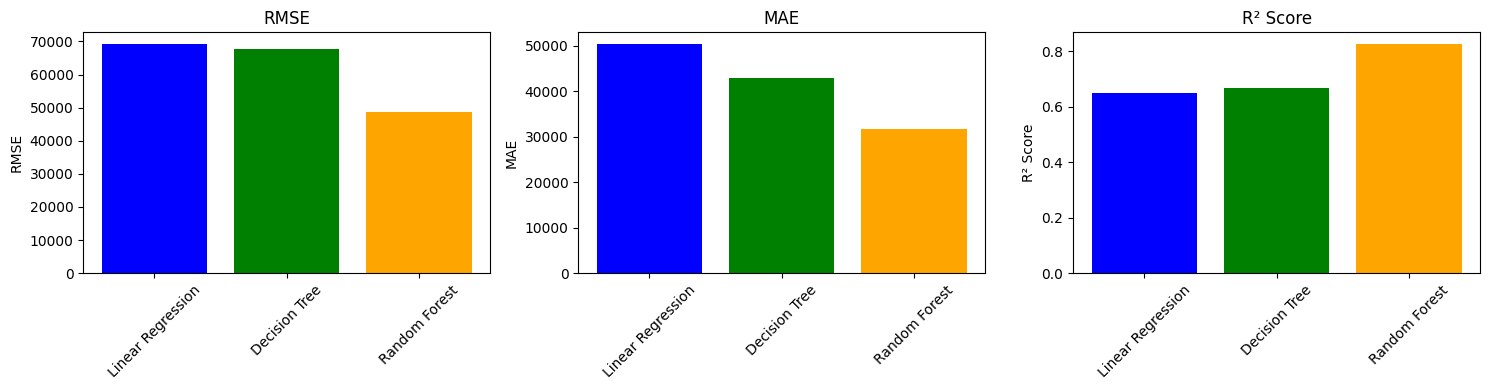

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(results_df['Model'], results_df['RMSE'], color=['blue', 'green', 'orange'])
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(results_df['Model'], results_df['MAE'], color=['blue', 'green', 'orange'])
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(results_df['Model'], results_df['R² Score'], color=['blue', 'green', 'orange'])
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [79]:
best_model_name = results_df.loc[results_df['R² Score'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"R² Score: {results_df.loc[results_df['R² Score'].idxmax(), 'R² Score']:.4f}")

Best Model: Random Forest
R² Score: 0.8260


## Predictions

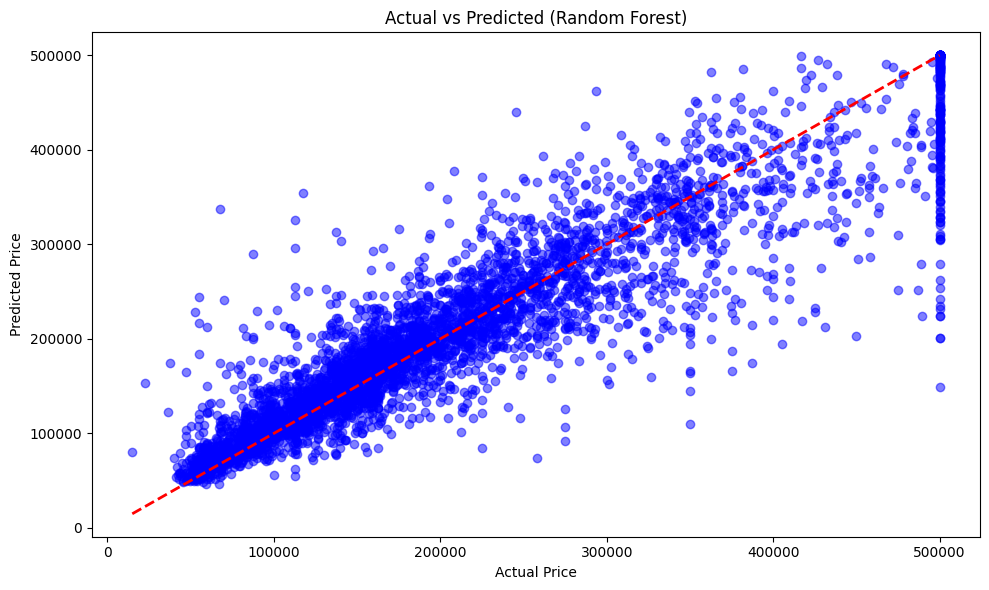

In [80]:
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.tight_layout()
plt.show()

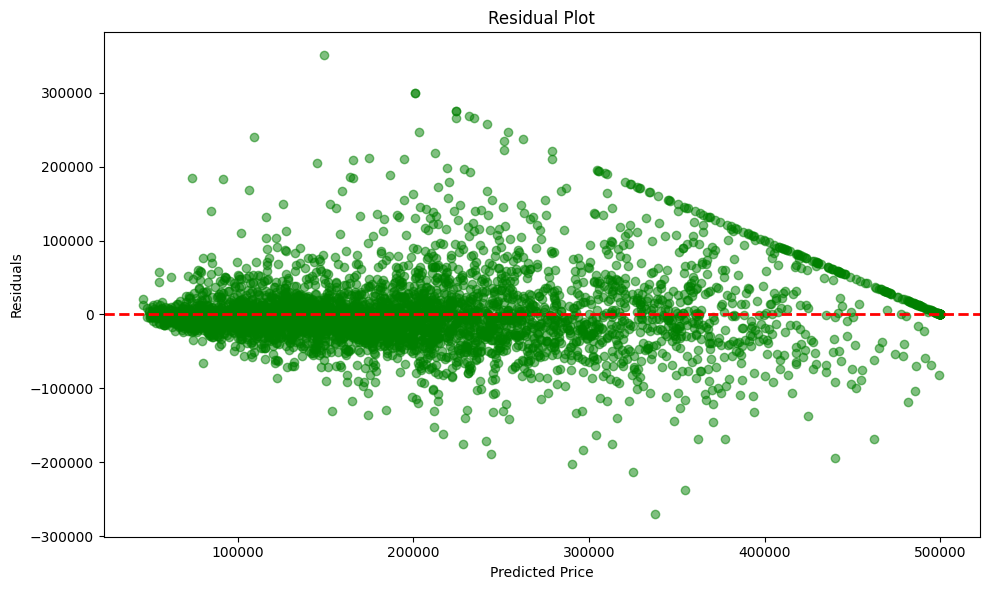

In [81]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title(f'Residual Plot')
plt.tight_layout()
plt.show()

## Feature Importance

                       Feature  Importance
7                median_income    0.485142
8       ocean_proximity_INLAND    0.142842
0                    longitude    0.109385
1                     latitude    0.104899
2           housing_median_age    0.050458
5                   population    0.032718
3                  total_rooms    0.023751
4               total_bedrooms    0.021996
6                   households    0.018917
11  ocean_proximity_NEAR OCEAN    0.008189
10    ocean_proximity_NEAR BAY    0.001384
9       ocean_proximity_ISLAND    0.000318


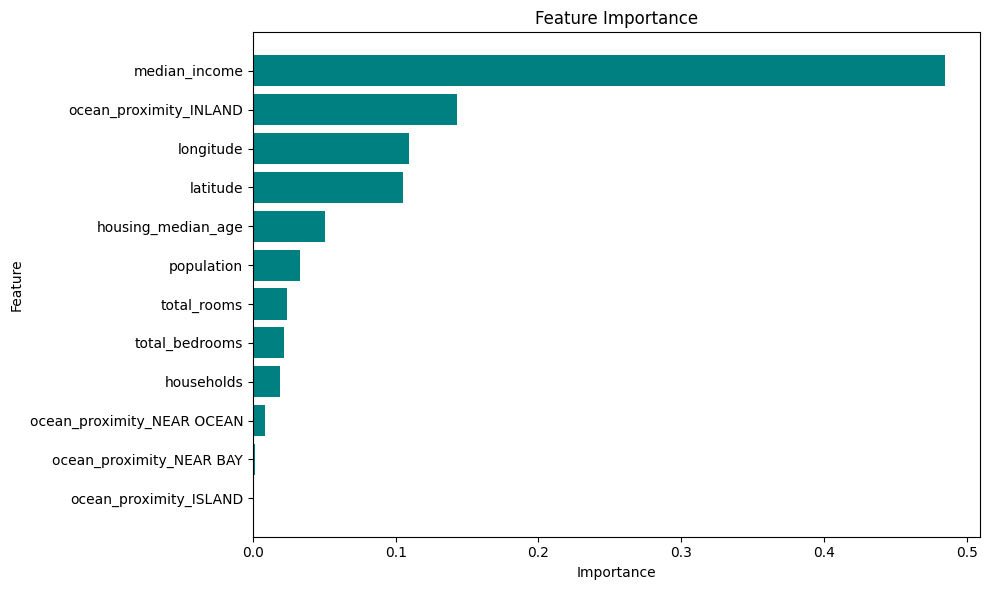

In [82]:
if best_model_name == 'Random Forest':
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not provide feature importance")

## Sample Predictions

In [83]:
sample_house = X_test.iloc[0:5].copy()
sample_house_scaled = scaler.transform(sample_house)
predictions = best_model.predict(sample_house_scaled)

print("Sample Predictions:")
for i, pred in enumerate(predictions):
    actual = y_test.iloc[i]
    print(f"House {i+1}: Predicted=${pred:.2f}, Actual=${actual:.2f}, Error=${abs(pred-actual):.2f}")

y_pred_all = best_model.predict(X_test_scaled)
accuracy_percentage = r2_score(y_test, y_pred_all) * 100

print(f"\nModel Accuracy: {accuracy_percentage:.2f}%")

Sample Predictions:
House 1: Predicted=$218806.00, Actual=$245800.00, Error=$26994.00
House 2: Predicted=$151202.00, Actual=$137900.00, Error=$13302.00
House 3: Predicted=$190018.00, Actual=$218200.00, Error=$28182.00
House 4: Predicted=$146361.00, Actual=$220800.00, Error=$74439.00
House 5: Predicted=$168285.00, Actual=$170500.00, Error=$2215.00

Model Accuracy: 82.60%


## Custom Prediction (User Input)

In [84]:
print("Enter house features for prediction:")
print(f"\nFeature names: {list(X.columns)}")
print(f"\nExample values from dataset:")
print(X.iloc[0])

user_input = {}
for feature in X.columns:
    value = float(input(f"\nEnter {feature}: "))
    user_input[feature] = value

user_df = pd.DataFrame([user_input])
user_scaled = scaler.transform(user_df)
predicted_price = best_model.predict(user_scaled)[0]

print(f"\n{'='*50}")
print(f"Predicted House Price: ${predicted_price:,.2f}")
print(f"{'='*50}")

Enter house features for prediction:

Feature names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Example values from dataset:
longitude                    -122.2300
latitude                       37.8800
housing_median_age             41.0000
total_rooms                   880.0000
total_bedrooms                129.0000
population                    322.0000
households                    126.0000
median_income                   8.3252
ocean_proximity_INLAND          0.0000
ocean_proximity_ISLAND          0.0000
ocean_proximity_NEAR BAY        1.0000
ocean_proximity_NEAR OCEAN      0.0000
Name: 0, dtype: float64

Predicted House Price: $470,657.72


## Quick Custom Prediction (Manual Entry)

In [85]:
custom_values = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41.0,
    'total_rooms': 880.0,
    'total_bedrooms': 129.0,
    'population': 322.0,
    'households': 126.0,
    'median_income': 8.3252,
    'ocean_proximity_INLAND': 0.0,
    'ocean_proximity_ISLAND': 0.0,
    'ocean_proximity_NEAR BAY': 1.0,
    'ocean_proximity_NEAR OCEAN': 0.0
}

custom_df = pd.DataFrame([custom_values])

missing_cols = set(X.columns) - set(custom_df.columns)
for col in missing_cols:
    custom_df[col] = 0.0

custom_df = custom_df[X.columns]

custom_scaled = scaler.transform(custom_df)
predicted_price = best_model.predict(custom_scaled)[0]

print("Custom House Features:")
print(custom_df.T)
print(f"\nPredicted House Price: ${predicted_price:,.2f}")

Custom House Features:
                                   0
longitude                  -122.2300
latitude                     37.8800
housing_median_age           41.0000
total_rooms                 880.0000
total_bedrooms              129.0000
population                  322.0000
households                  126.0000
median_income                 8.3252
ocean_proximity_INLAND        0.0000
ocean_proximity_ISLAND        0.0000
ocean_proximity_NEAR BAY      1.0000
ocean_proximity_NEAR OCEAN    0.0000

Predicted House Price: $449,321.37
